# Model Laboratory — Intelligent Commodity Price Prediction
### SAIL Durgapur Steel Plant · Procurement Decision Engine

This notebook is the audit trail of the forecasting engine behind the DSP
Commodity Intelligence dashboard. It walks the exact pipeline the production
system uses — same code, imported from `src/` — so what you verify here is
what runs in the app:

1. raw PO audit and the partial-delivery pricing trap
2. leakage-safe monthly series construction
3. a 19-model zoo + 4 ensemble strategies, refereed by chronological
   walk-forward on an 80/20 split of *observed* months
4. per-commodity champion selection (whatever honestly wins, wins)
5. forecast generation with empirical uncertainty bands
6. the fuzzy buy-timing verdict, negotiation bands and inventory maths

Every output below was produced by executing the cell against the real
workbook `data/raw/DATA_COMMODITY__PRICING.XLSX`. Nothing is illustrative or
hand-typed.

In [2]:
import warnings, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.facecolor':'white','axes.grid':True,
                     'grid.alpha':.3,'figure.dpi':110})

from src.data_pipeline import load_raw, resolve_prices, load_table, PROC

raw = load_raw()
print(f"PO lines            : {len(raw):,}")
print(f"Date span           : {raw['PO Date'].min():%d %b %Y} -> {raw['PO Date'].max():%d %b %Y}")
print(f"Distinct materials  : {raw['commodity'].nunique():,}")
print(f"Zero-qty lines      : {(raw['Quantity Received']==0).sum()}")
print(f"Zero-value lines    : {(raw['Total PO Value']==0).sum()}")
print(f"POs per material    : median {raw.groupby('commodity').size().median():.0f}, "
      f"max {raw.groupby('commodity').size().max()}")

PO lines            : 21,441
Date span           : 26 Feb 2015 -> 31 Jul 2026
Distinct materials  : 5,792
Zero-qty lines      : 567
Zero-value lines    : 195
POs per material    : median 2, max 109


## 1 · The pricing trap hiding in plain sight

A unit price looks trivial: `Total PO Value ÷ Quantity Received`. But for
recent purchase orders the receipt is often **partial** while the recorded
value is the **full** order — so the naive division fabricates a price spike
that never happened. Watch it on the plant's single biggest spend item:

In [4]:
d0 = raw[raw['commodity']=='SILICO MANGANESE,25 TO 50 MM'].copy()
d0['naive_unit'] = d0['Total PO Value']/d0['Quantity Received']
d0['est_unit']   = d0['PR Est Value']/d0['PR Qty.']
cols = ['PO Date','Quantity Received','naive_unit','est_unit']
print("Naive unit price — last 6 POs of Silico Manganese:")
print(d0.sort_values('PO Date')[cols].tail(6).to_string(index=False,
      float_format=lambda x: f'{x:,.0f}'))
print("\nThe May-2026 'prices' of ~2.5–2.8 lakh/T are pure artefact: only a"
      "\nfraction of the tonnage had been received against the full PO value.")

Naive unit price — last 6 POs of Silico Manganese:
   PO Date  Quantity Received  naive_unit  est_unit
2026-02-03              6,461      70,965    70,953
2026-02-03              5,938      70,970    70,953
2026-02-03                522      71,084    70,953
2026-02-03              4,573      70,997    70,953
2026-05-22              2,413     254,185    74,949
2026-05-22              2,593     283,827    74,949

The May-2026 'prices' of ~2.5–2.8 lakh/T are pure artefact: only a
fraction of the tonnage had been received against the full PO value.


The pipeline resolves this with a provenance-tagged cascade, per
commodity: anchor a robust log-price band on estimate-consistent history
(median ± 3.5 MAD), then accept the PO rate when it fits, fall back to
`value ÷ PR-quantity`, then to the estimate rate, and quarantine the rest.
Nothing is silently altered — every substitution carries a visible flag and
the rejects live in `quarantine_audit`.

In [6]:
res = resolve_prices(raw)
counts = res['provenance'].value_counts()
print("Price provenance across all", f"{len(res):,}", "PO lines:")
print(counts.to_string())
fixed = res[(res['commodity']=='SILICO MANGANESE,25 TO 50 MM')].sort_values('PO Date')
print("\nSame six Silico-Manganese lines, after resolution:")
print(fixed[['PO Date','po_unit','resolved_price','provenance']].tail(6)
      .to_string(index=False, float_format=lambda x: f'{x:,.0f}'))

Price provenance across all 21,441 PO lines:
provenance
OK                19489
RESOLVED_PRQTY      773
RESOLVED_EST        669
DROPPED             510

Same six Silico-Manganese lines, after resolution:
   PO Date  po_unit  resolved_price   provenance
2026-02-03   70,965          70,965           OK
2026-02-03   70,970          70,970           OK
2026-02-03   71,084          71,084           OK
2026-02-03   70,997          70,997           OK
2026-05-22  254,185          74,949 RESOLVED_EST
2026-05-22  283,827          74,949 RESOLVED_EST


## 2 · Monthly series without time-travel

Prices aggregate to **quantity-weighted monthly** figures. Models need a
regular grid, so gap months are log-linearly interpolated — but at
evaluation time the grid is rebuilt at every step **from past observations
only**, so a future PO can never leak backwards through the interpolation.
Accuracy is scored *exclusively* on months containing a real purchase.

Commodities on file: 5,698 | eligible for full ML treatment (≥20 priced POs across ≥12 observed months): 102


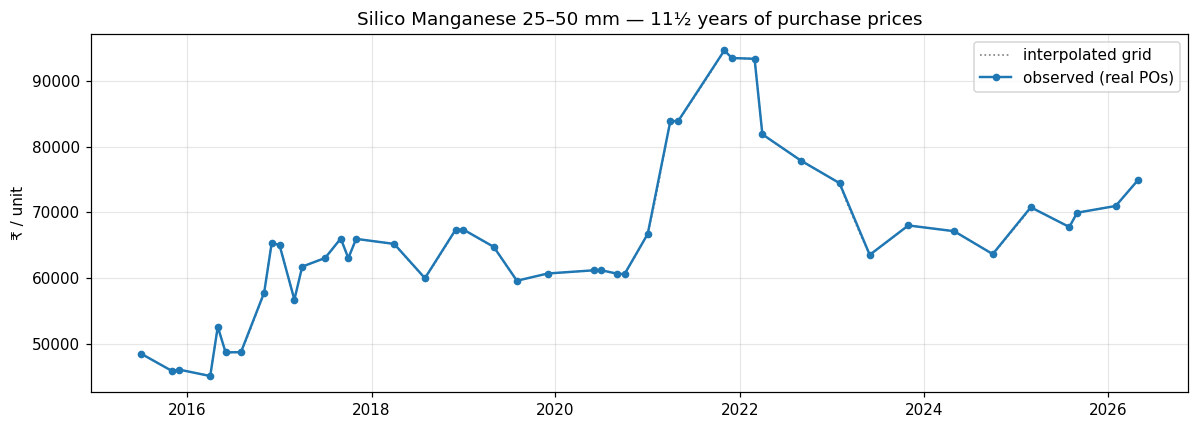

In [8]:
monthly = load_table('monthly_prices')
sm = monthly[monthly['commodity']=='SILICO MANGANESE,25 TO 50 MM']
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(sm['month'], sm['price_filled'], ':', lw=1.1, color='grey',
        label='interpolated grid')
o = sm[sm['observed']]
ax.plot(o['month'], o['price'], 'o-', ms=4, lw=1.6, color='#1f77b4',
        label='observed (real POs)')
ax.set_title('Silico Manganese 25–50 mm — 11½ years of purchase prices')
ax.set_ylabel('₹ / unit'); ax.legend()
plt.tight_layout()
cat = load_table('catalog')
print(f"Commodities on file: {len(cat):,} | eligible for full ML treatment "
      f"(≥20 priced POs across ≥12 observed months): {cat['modelable'].sum()}")

## 3 · The zoo and the referee

**Nineteen forecasters** compete on every commodity — statistical methods
implemented from first principles (naive, seasonal-naive, drift, moving
average, SES, Holt with auto-damping, Holt-Winters, **Theta**, linear trend,
ridge autoregression) and machine-learning models on lag/rolling/seasonality
features (random forest, extra trees, gradient boosting, hist gradient
boosting, SVR, k-NN, a small MLP neural net, Bayesian ridge, Gaussian
process) — plus **four ensembles**: top-5 mean, inverse-error weights,
**simulated-annealing-optimised weights** (scipy `dual_annealing`, the
classical member of the quantum-inspired metaheuristic family) and greedy
forward selection.

```
observed months ────────────────────────────────────────────► time
|──────────────── ~80% train ────────────────|──── ~20% test ────|
                          |─ inner val ─|
                     ensemble weights learned here ONLY
```

The referee is chronological walk-forward: each scored month is forecast
using only earlier observations, across the **true gap** to the next real PO
— when the plant went four months between orders, the model is judged on a
genuine four-step-ahead call. Here is the referee running live on one
commodity:

In [10]:
from src.backtest import evaluate_commodity
lb1, preds1, champ1 = evaluate_commodity(monthly, 'FERRO MANGANESE,25-50MM')
print(f"Champion: {champ1['model']}  |  test MAPE {champ1['mape']*100:.1f}% "
      f"on {champ1['n_test']} held-out months (mean horizon "
      f"{champ1['mean_h']:.1f} m)\n")
show = lb1.sort_values('mape').head(10)[['model','kind','mape','rmse','mase']]
show['mape'] = (show['mape']*100).round(1)
print(show.to_string(index=False))

Champion: Holt-Winters seasonal  |  test MAPE 2.9% on 6 held-out months (mean horizon 4.2 m)

                     model     kind  mape        rmse     mase
     Holt-Winters seasonal   single   2.9 2274.732867 0.297026
   Moving average (auto-k)   single   3.8 3343.857615 0.390601
Ensemble: greedy selection ensemble   4.0 3380.877739 0.406488
              Theta method   single   4.0 3232.501841 0.415559
Ensemble: annealed weights ensemble   4.0 3485.657491 0.418105
               Extra trees   single   4.0 3419.799673 0.416963
   Ensemble: inverse-error ensemble   4.1 3247.454050 0.416651
      Ensemble: top-5 mean ensemble   4.1 3366.916481 0.417569
                     Drift   single   4.2 3187.101417 0.429096
     Simple exp. smoothing   single   4.2 3473.916840 0.434124


## 4 · Championship across all 102 commodities

The full bake-off (`python -m src.train_all`) referees every eligible
commodity and checkpoints as it goes. Its artifacts drive everything below —
and the headline finding is exactly why per-commodity selection matters:
**no single algorithm rules**.

Distinct champion algorithms : 20
Ensemble championships       : 4
MAPE quartiles               : [4.2, 7.2, 11.3] %


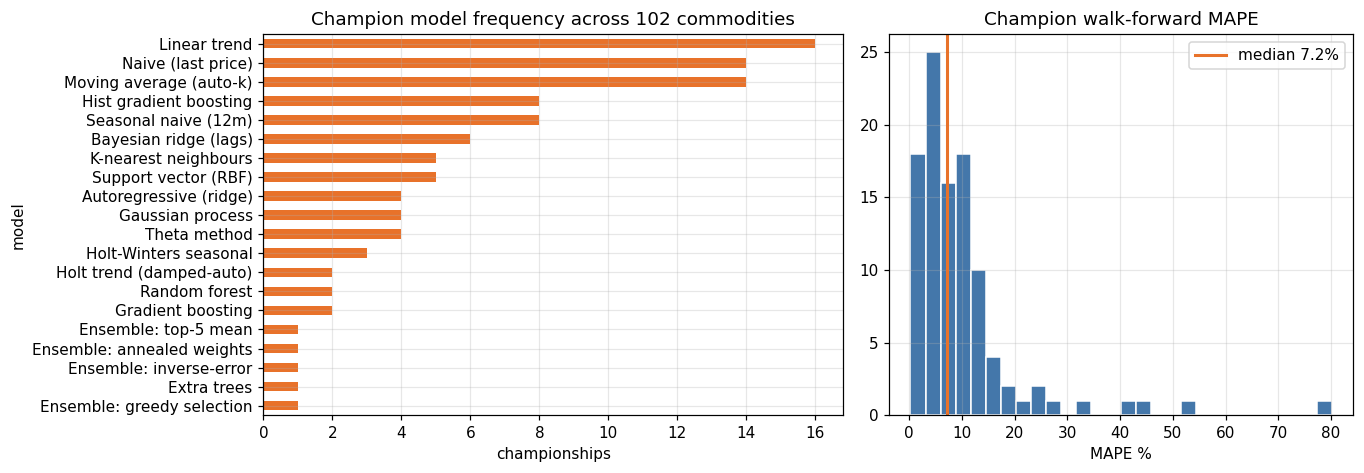

In [12]:
champs = pd.read_json(PROC/'champions.jsonl', lines=True)
lb = pd.read_csv(PROC/'leaderboard.csv')
freq = champs['model'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12.5,4.4),
                         gridspec_kw={'width_ratios':[1.25,1]})
freq.sort_values().plot.barh(ax=axes[0], color='#E8722A')
axes[0].set_title(f'Champion model frequency across {len(champs)} commodities')
axes[0].set_xlabel('championships')
axes[1].hist(champs['mape']*100, bins=28, color='#4477AA', edgecolor='white')
axes[1].axvline(champs['mape'].median()*100, color='#E8722A', lw=2,
                label=f"median {champs['mape'].median()*100:.1f}%")
axes[1].set_title('Champion walk-forward MAPE'); axes[1].set_xlabel('MAPE %')
axes[1].legend()
plt.tight_layout()
print(f"Distinct champion algorithms : {champs['model'].nunique()}")
print(f"Ensemble championships       : "
      f"{champs['model'].str.startswith('Ensemble').sum()}")
print(f"MAPE quartiles               : "
      f"{(champs['mape'].quantile([.25,.5,.75])*100).round(1).tolist()} %")

In [13]:
cat = load_table('catalog')
top = cat[cat['modelable']].head(15)[['commodity','total_spend']].merge(
    champs[['commodity','model','mape','n_test']], on='commodity')
top['spend ₹Cr'] = (top['total_spend']/1e7).round(1)
top['MAPE %'] = (top['mape']*100).round(1)
print('Top-15 spend commodities — who forecasts them best:')
print(top[['commodity','spend ₹Cr','model','MAPE %','n_test']]
      .to_string(index=False))

Top-15 spend commodities — who forecasts them best:
                               commodity  spend ₹Cr                   model  MAPE %  n_test
            SILICO MANGANESE,25 TO 50 MM     2810.5 Moving average (auto-k)     5.5       9
                     BOF STEEL LADLE SET      790.2    Seasonal naive (12m)    26.6       7
                   FERRO SILICON,25-50MM      767.7      Naive (last price)     6.6       8
             FERRO VANADIUM,IS:1466-1985      364.6    Seasonal naive (12m)     8.2       7
        LINING,TUNDISH FOR BILLET CASTER      152.4    K-nearest neighbours     9.3       4
           LINING,TUNDISH F/BLOOM CASTER      145.4    Support vector (RBF)    25.4       3
GRAPHITE ELECTRODE ,IS:9050,457MM,1800MM      144.2    Ensemble: top-5 mean     1.3       3
                 FERRO MANGANESE,25-50MM      132.8   Holt-Winters seasonal     2.9       6
          CASTABLE,LOW CEMENT GEL BONDED      131.7            Linear trend    13.3       6
         TAP HOLE MASS,TYPE:

## 5 · Seeing the held-out test with your own eyes

Four marquee commodities, actual vs champion prediction on the untouched
final 20% — every point a genuine walk-forward forecast:

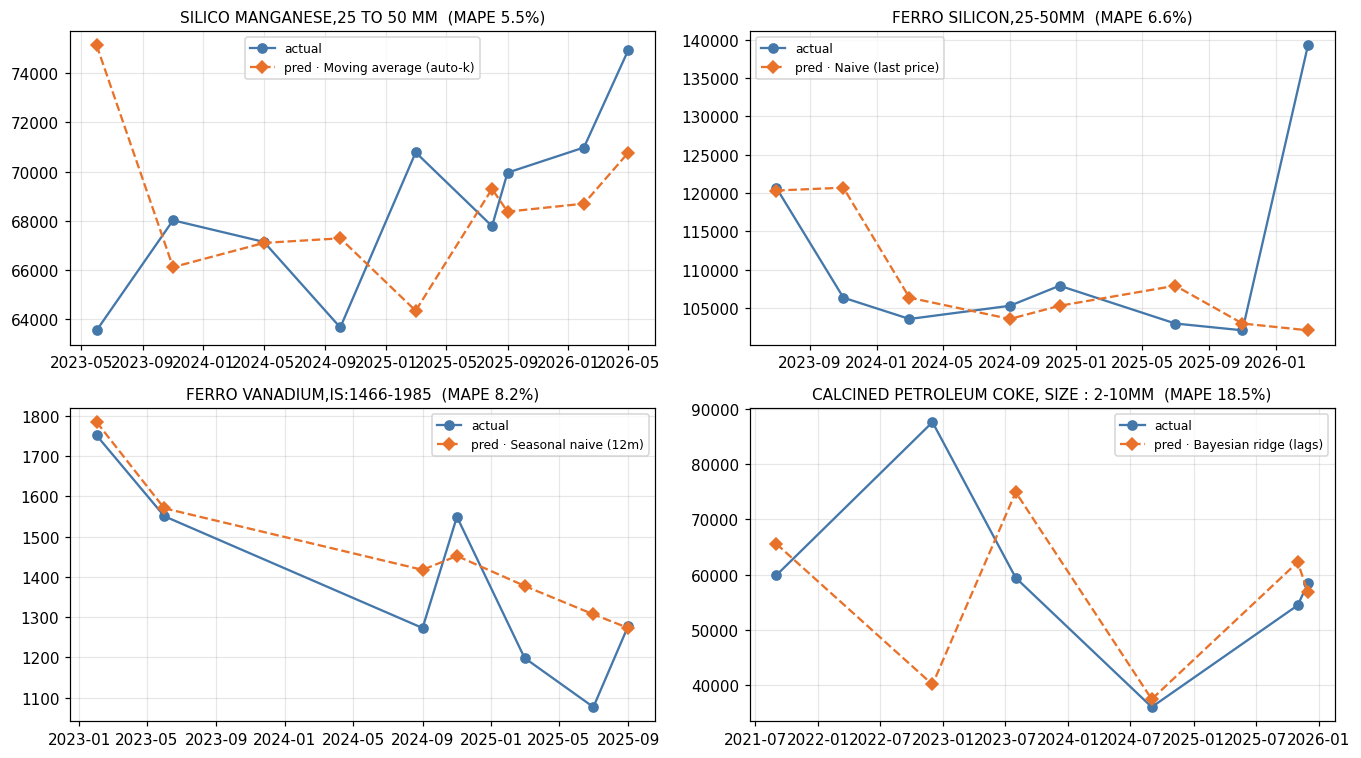

In [15]:
tp = pd.read_csv(PROC/'test_predictions.csv', parse_dates=['month'])
marquee = ['SILICO MANGANESE,25 TO 50 MM','FERRO SILICON,25-50MM',
           'FERRO VANADIUM,IS:1466-1985','CALCINED PETROLEUM COKE, SIZE : 2-10MM']
fig, axes = plt.subplots(2,2, figsize=(12.5,7))
for ax, com in zip(axes.ravel(), marquee):
    ch = champs.set_index('commodity').loc[com,'model']
    t = tp[(tp['commodity']==com)&(tp['model']==ch)].sort_values('month')
    ax.plot(t['month'], t['actual'], 'o-', label='actual', color='#4477AA')
    ax.plot(t['month'], t['pred'], 'D--', label=f'pred · {ch}', color='#E8722A')
    m = champs.set_index('commodity').loc[com,'mape']*100
    ax.set_title(f"{com[:38]}  (MAPE {m:.1f}%)", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()

## 6 · Where the ensembles earn their keep

Ensembles win outright only where blending genuinely beats the best single
model on held-out data — the referee doesn't hand out style points. Graphite
electrodes is one such case:

In [17]:
com = 'GRAPHITE ELECTRODE ,IS:9050,457MM,1800MM'
g = lb[lb['commodity']==com].sort_values('mape').head(8)
g = g[['model','kind','mape','rmse']].copy(); g['mape']=(g['mape']*100).round(2)
print(f'{com} — top of the leaderboard:')
print(g.to_string(index=False))
wins = champs[champs['model'].str.startswith('Ensemble')]
print('\nAll ensemble championships:')
print(wins[['commodity','model','mape']].assign(
      mape=lambda d:(d['mape']*100).round(1)).to_string(index=False))

GRAPHITE ELECTRODE ,IS:9050,457MM,1800MM — top of the leaderboard:
                     model     kind  mape      rmse
      Ensemble: top-5 mean ensemble  1.26  3.634447
        Naive (last price)   single  1.47  4.406904
Ensemble: greedy selection ensemble  1.47  4.406904
     Simple exp. smoothing   single  1.57  4.739753
   Ensemble: inverse-error ensemble  1.84  5.892976
   Moving average (auto-k)   single  2.35  7.592208
              Theta method   single  2.67  9.406175
      K-nearest neighbours   single  3.95 13.675792

All ensemble championships:
                               commodity                      model  mape
                            MCCB,100A,3P Ensemble: greedy selection  14.2
          CABLE TIE,TYPE:6/6,DIA:101.6MM Ensemble: annealed weights   7.8
       TERMINAL END,RING TORQUE,CU,16MM2    Ensemble: inverse-error   4.5
GRAPHITE ELECTRODE ,IS:9050,457MM,1800MM       Ensemble: top-5 mean   1.3


## 7 · Production forecasts and honest uncertainty

Champions are refit on the **full** observed history and pushed 12 months
ahead. Bands are empirical — the champion's own held-out error distribution,
widened with horizon (√h), labelled ~80% coverage because that is what the
backtest says, not what a formula promises.

     month    p50    p10    p90
2026-06-01 73,602 69,444 77,759
2026-07-01 73,602 69,444 77,759
2026-08-01 73,602 69,278 77,925
2026-09-01 73,602 68,609 78,594
2026-10-01 73,602 68,019 79,184
2026-11-01 73,602 67,487 79,717


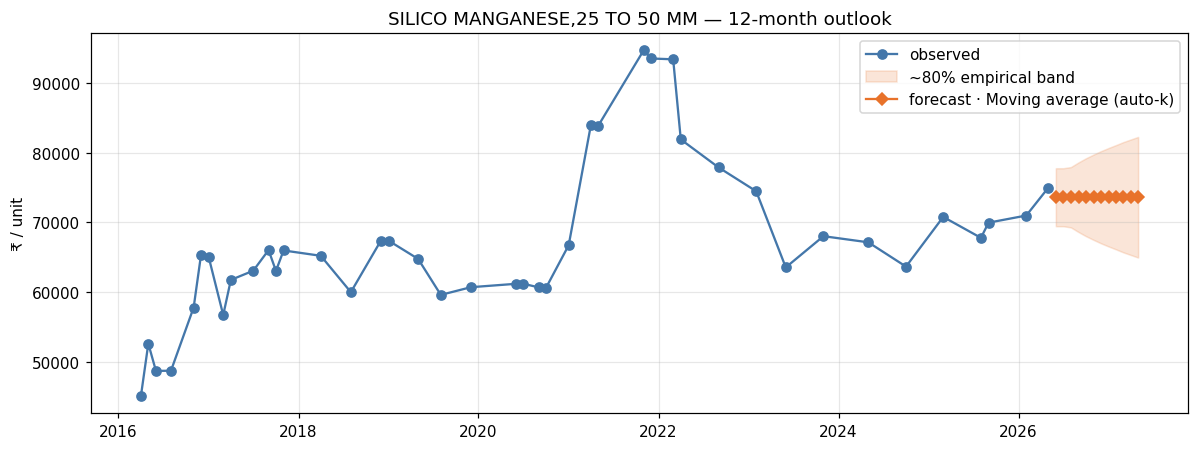

In [19]:
fc = pd.read_csv(PROC/'forecasts.csv', parse_dates=['month'])
com='SILICO MANGANESE,25 TO 50 MM'
o = monthly[(monthly['commodity']==com)&(monthly['observed'])].tail(42)
f = fc[fc['commodity']==com]
fig, ax = plt.subplots(figsize=(11,4.2))
ax.plot(o['month'], o['price'],'o-',color='#4477AA',label='observed')
ax.fill_between(f['month'], f['p10'], f['p90'], color='#E8722A', alpha=.18,
                label='~80% empirical band')
ax.plot(f['month'], f['p50'],'D-',color='#E8722A',
        label=f"forecast · {f['model'].iloc[0]}")
ax.set_title(f'{com} — 12-month outlook'); ax.set_ylabel('₹ / unit'); ax.legend()
plt.tight_layout()
print(f[['month','p50','p10','p90']].head(6).to_string(index=False,
      float_format=lambda x:f'{x:,.0f}'))

## 8 · From forecast to verdict — the decision layer

A **Mamdani fuzzy-inference system** (12 rules, trapezoidal memberships,
centroid defuzzification, implemented from first principles in
`src/decision_engine.py`) fuses four crisp inputs into one 0–100 buy-timing
score:

| input | meaning |
|---|---|
| expected move | forecast Δ over the decision horizon |
| momentum | slope of the last ~6 observed prices |
| urgency | months since last PO ÷ the commodity's own median cycle |
| volatility | CV of the last 12 observed prices |

Negotiation bands come from the commodity's real record — quartiles of
PO-price ÷ PR-estimate, tender-mode bargaining power — blended with the
forecast into open / target / walk-away anchors, plus a labelled
game-theory-informed counter-offer rule. Inventory uses classical EOQ,
safety-stock and reorder mathematics with every economic input exposed as a
dial in the dashboard (the data records no lead times, so lead time is an
explicit assumption, never a hidden constant).

In [21]:
from src.decision_engine import fuzzy_buy_signal
scenarios = [
    ('Prices rising, cycle overdue',      +0.06, +0.02, 1.4, 0.05),
    ('Prices falling, plenty of cover',   -0.06, -0.02, 0.3, 0.05),
    ('Flat & volatile, cycle due',         0.00,  0.00, 1.0, 0.20)]
for name, mv, mo, ur, vol in scenarios:
    s = fuzzy_buy_signal(mv, mo, ur, vol)
    print(f"{name:38s} -> {s['label']:13s} score {s['score']:5.1f}")
    print(f"{'':40s}» {s['reasons'][0]}")
sig = json.loads((PROC/'decision_signals.json').read_text())
sm = sig['signals']['SILICO MANGANESE,25 TO 50 MM']
print(f"\nLive verdict · Silico Manganese: {sm['label']} "
      f"(score {sm['score']}), Δ3m {sm['exp_move_3m']*100:+.1f}%, "
      f"urgency {sm['urgency']:.2f}")
for r in sm['reasons']: print('  »', r)

Prices rising, cycle overdue           -> BUY NOW       score  89.0
                                        » Prices expected to rise and the ordering cycle is overdue — cover now.
Prices falling, plenty of cover        -> HOLD OFF      score  10.7
                                        » Prices expected to soften and stock position allows waiting.
Flat & volatile, cycle due             -> MONITOR       score  50.0
                                        » Stable prices, normal cycle position — proceed on routine timing.

Live verdict · Silico Manganese: BUY / STAGGER (score 65.9), Δ3m -1.8%, urgency 1.35
  » Stable prices and an overdue cycle — replenish at prevailing rates.
  » Stable prices, normal cycle position — proceed on routine timing.


## 9 · Optional extensions (run with internet / extra installs)

The engine is deliberately dependency-light so the identical code runs on
Streamlit Cloud, a plant desktop, or an air-gapped machine. Two optional
extensions slot in without touching the referee:

* **Extended zoo** — SARIMA (`statsmodels`), XGBoost, Prophet, or an LSTM
  can be added to `model_zoo()`; the walk-forward referee scores them under
  identical rules, and they win championships only if they earn them.
* **External regressors** — `src/external_data.py` pulls global benchmarks
  (iron ore, coking coal, Brent, USD/INR, WPI…) from FRED's keyless endpoint
  and yfinance, cached to disk. The dashboard's Market Pulse page computes
  lead-lag correlations against each commodity; indices showing strong lag-1/
  lag-2 correlation are candidates for exogenous features in a future
  iteration.

The guard below shows the pattern — it skips politely where the extras are
absent and activates where they exist:

In [23]:
for lib in ('statsmodels','xgboost','prophet'):
    try:
        __import__(lib); print(f"{lib:12s}: available — extended zoo can use it")
    except ImportError:
        print(f"{lib:12s}: not installed — skipped (optional)")
try:
    from src.external_data import load_external
    ext, status = load_external(max_age_hours=1e9)  # cache-only in this run
    print('external cache:', 'empty — will populate on first online run'
          if ext.empty else f'{ext.shape[1]} series cached')
except Exception as e:
    print('external module guard worked:', type(e).__name__)

statsmodels : not installed — skipped (optional)
xgboost     : not installed — skipped (optional)
prophet     : not installed — skipped (optional)
external cache: empty — will populate on first online run


## 10 · Reproducing and retraining

```bash
pip install -r requirements.txt
python -m src.train_all --refresh    # full pipeline + bake-off (~20 min)
python smoke_test.py                 # verify before launching
streamlit run app.py
```

Drop a newer SAP export over `data/raw/DATA_COMMODITY__PRICING.XLSX` and
rerun — champions are re-selected from scratch against the new data. That
re-selection **is** the self-learning loop: the day a commodity's behaviour
changes, whatever model now wins the walk-forward test takes over its
forecasts. The referee stays; the champions rotate.